# <font color='#000000'>Master Thesis Hugo Alves | <span style="color:#BFD62F;">__Nova__</span> <span style="color:#5C666C;">__IMS__</span></font>

Welcome to the third chapter of notebooks developed for this project. We (Professor Roberto Henriques, Professor Ricardo Santos, and Hugo Alves) aim to develop a machine learning (ML) framework to predict student admissions to postgraduate and masters' programs at Nova IMS, as well as the final grade point average (GPA) of those who are accepted.

<br>
<div align="center">
  <img src="https://i.ibb.co/BtH7KLZ/Notebooks-Workflow.png" alt="Workflow" width="800" />
</div>
<br>

After exploring and preprocessing our data, we finally arrive to the __modelling__ stage. Thus, the main focus of this notebook will be to create, select, and test the models to predict the final GPA of the admitted students, as well as understanding which variables most contribute to these predictions. Enjoy!


# <font color="#5C666C">Contents</font> <a class="anchor" id="toc"></a>
[Initial Setup](#setup)<br>
- [Library and Functions Import](#library)<br>
- [Retrieving the Dataframes](#dataframes)<br>
   
[4. Modelling](#modelling)<br>
- [4.1. Decision Tree](#dt)<br>
- [4.2. Linear Regression](#lr)<br>
- [4.3. Neural Network](#nn)<br>
- [4.4. Support Vector Machine](#svm)<br>
- [4.5. Random Forest](#rf)<br>
- [4.6. Bagging](#bagging)<br>
- [4.7. Adaptive Boosting](#ab)<br>
- [4.8. Gradient Boosting](#gb)<br>
- [4.9. Final Model Selection](#selection)<br>

[5. Evaluating variable importance](#shap)<br>

</div>

# <font color="#BFD62F">_____________</font>
# <font color='#5C666C'>Initial Setup</font> <a class="anchor" id="setup"></a>
[Back to Contents](#toc)

## <font color='#BFD62F'>Library and Functions Import</font> <a class="anchor" id="library"></a>
[Back to Contents](#toc)

We are using the Python version 3.11.8.

In [1]:
#! pip install pandas==2.2.1
#! pip install numpy==1.24.4
#! pip install matplotlib==3.8.3
#! pip install seaborn==0.12.2
#! pip install plotly==5.20.0
#! pip install tenacity==8.2.2
#! pip install openpyxl>=3.1.0
#% pip install nbformat>=4.3.0
#! pip install rapidfuzz==3.11.0
#! pip install xlrd==2.0.1
#! pip install sklearn==1.2.2
#! pip install imblearn==0.11.0
#! pip install shap==0.46.0

In [2]:
%run Imports

In [3]:
import Functions as tf

## <font color='#BFD62F'>Retrieving the Dataframes </font> <a class="anchor" id="dataframes"></a>
[Back to Contents](#toc)

Let's retrieve the dataframes that we used in the previous notebook.

In [4]:
%store -r X_grades_train_scaled
%store -r X_grades_val_scaled
%store -r y_grades_train
%store -r y_grades_val

%store -r numerical_variables_grades
%store -r binary_variables_grades
%store -r categorical_variables_grades

# <font color='#BFD62F'>______________</font>
# <font color='#5C666C'>4. Modelling </font> <a class="anchor" id="modelling"></a>
[Back to Contents](#toc)

It's finally time to start making predictions on the final GPA of the students that were admitted to Nova IMS' postgraduate and masters' programs.

We will start by testing some of the single models employed by the literature, namely the __Decision Tree__, __Logistic Regression__, __Artificial Neural Networks__, and __Support Vector Machines__. We will not use others, such as K-Nearest Neighbors (KNN) due to its simplicity and reliance on the available data, which we do not have in great numbers considering our less than 3 200 observations.
As for the ensemble models, we will utilize a __Random Forest__ to make predictions, as well as __Bagging__, __Adaptive Boosting__, and __Gradient Boosting__ algorithms. <br>

For each algorithm, the ideal hyperparameters will be determined through a grid search, which will hopefully return the closest to a global optimum of the model. We will utilize a function to fit the model to the training dataset and assess it on the validation data, returning the MAE, MSE, and RMSE as metrics. It will also save the model to a Pickle file, so that it can easily be retrieved without constantly needing to run the function.

__Note:__ To prevent running this notebook for a very long time, we will leave commented the code used for each algorithm. If needed, the models are stored in a Pickle file and can be called without the necessity to run the function again.

## <font color='#BFD62F'>4.1. Decision Tree </font> <a class="anchor" id="dt"></a>
[Back to Contents](#toc)

Decision trees are one of the simplest of ML algorithms. Essentially, they are a set of rules that leads some input data from the root node (the first in the tree) down to a leaf node, where all variables belonging to that leaf are assigned to a certain label. From the root node, all instances of the data are partitioned, using a value for a certain variable as a condition. All variables are tested, and the one that displays the highest predictive power is set as the condition for the root node. The data is split according to whether they match the winning condition, and the process is repeated for each of the new nodes that originated from the split. The final prediction is made by taking the average of the target values of the training data, for the leaf node to which the new observation belongs.

In [5]:
"""
%%time

dt_grades = DecisionTreeRegressor(random_state=92)

dt_param_grid = {
    "criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"],
    "max_depth": [None, 4, 6, 8, 10, 12, 14],
    "min_samples_split": [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],
    "min_samples_leaf": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],
    "max_features": [None, 0.1, 0.3, 0.5, 0.7, 0.9],
    "max_leaf_nodes": [None, 5, 10, 20, 30],
    "min_impurity_decrease": [0, 0.01, 0.05]
}

dt_best_params, dt_y_pred, dt_mae, dt_mse, dt_rmse = tf.run_model_regression(dt_grades,
                                                                             dt_param_grid,
                                                                             X_grades_train_scaled,
                                                                             y_grades_train,
                                                                             X_grades_val_scaled,
                                                                             y_grades_val,
                                                                             "neg_root_mean_squared_error",
                                                                             True,
                                                                             "Decision_Tree")
"""

'\n%%time\n\ndt_grades = DecisionTreeRegressor(random_state=92)\n\ndt_param_grid = {\n    "criterion": ["squared_error", "friedman_mse", "absolute_error", "poisson"],\n    "max_depth": [None, 4, 6, 8, 10, 12, 14],\n    "min_samples_split": [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],\n    "min_samples_leaf": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5],\n    "max_features": [None, 0.1, 0.3, 0.5, 0.7, 0.9],\n    "max_leaf_nodes": [None, 5, 10, 20, 30],\n    "min_impurity_decrease": [0, 0.01, 0.05]\n}\n\ndt_best_params, dt_y_pred, dt_mae, dt_mse, dt_rmse = tf.run_model_regression(dt_grades,\n                                                                             dt_param_grid,\n                                                                             X_grades_train_scaled,\n                                                                             y_grades_train,\n                                                                             X_grades_val_scaled,\n                     

## <font color='#BFD62F'>4.2. Linear Regression </font> <a class="anchor" id="lr"></a>
[Back to Contents](#toc)

This statistical algorithm attempts to model the relationship between independent variables and a dependent one. The regression line (the one that best fits the data) is determined using the least squares method, which aims to minimize the distance between the estimated and the actual values.

In [6]:
"""
%%time

lr_grades = LinearRegression()

lr_param_grid = {
    "fit_intercept": [True, False]
}

lr_best_params, lr_y_pred, lr_mae, lr_mse, lr_rmse = tf.run_model_regression(lr_grades,
                                                                             lr_param_grid,
                                                                             X_grades_train_scaled,
                                                                             y_grades_train,
                                                                             X_grades_val_scaled,
                                                                             y_grades_val,
                                                                             "neg_root_mean_squared_error",
                                                                             True,
                                                                             "Linear_Regression")
"""

'\n%%time\n\nlr_grades = LinearRegression()\n\nlr_param_grid = {\n    "fit_intercept": [True, False]\n}\n\nlr_best_params, lr_y_pred, lr_mae, lr_mse, lr_rmse = tf.run_model_regression(lr_grades,\n                                                                             lr_param_grid,\n                                                                             X_grades_train_scaled,\n                                                                             y_grades_train,\n                                                                             X_grades_val_scaled,\n                                                                             y_grades_val,\n                                                                             "neg_root_mean_squared_error",\n                                                                             True,\n                                                                             "Linear_Regression")\n'

## <font color='#BFD62F'>4.3. Neural Network </font> <a class="anchor" id="nn"></a>
[Back to Contents](#toc)

Artificial neural networks are computing systems that attempt to mimic the animals' biological neural networks. It is composed of several perceptrons - single units of logic that output a binary conclusion - that can be organized in a number of layers through which the input data is passed.

At the first iteration of a neural network, the input data is passed onto the first layer of nodes (perceptrons), which receives the name of input layer. Each value and variable of the input data are assigned a random weight, increasing or decreasing its relevance when it arrives to the input layer. Inside each node, an activation function transforms the input into an output, before passing it to the next layer (also with higher or lower random weights), where the process is repeated until the data arrives at the output layer, that returns a final prediction. The main goal is to optimize the weights and reduce the prediction error (loss), which is done through backpropagation and several iterations of the data passing through the nodes, where each should, ideally, be closer to an accurate prediction.

In [7]:
"""
%%time

nn_grades = MLPRegressor(random_state = 92)

nn_param_grid = {
    "hidden_layer_sizes": [(100,), (100, 100), (100, 50), (50,), (50, 50), (50, 25)],
    "activation": ["relu", "logistic", "tanh"],
    "solver": ["adam", "sgd"],
    "alpha": [0.00001, 0.0001, 0.0005, 0.001, 0.01, 0.1],
    "learning_rate": ["constant", "invscaling", "adaptive"],
    "batch_size": [50, 100, 200, 500],
    "learning_rate_init": [0.0001, 0.001, 0.005, 0.01, 0.1],
    "max_iter": [5, 10, 20, 50, 100]
}

nn_best_params, nn_y_pred, nn_mae, nn_mse, nn_rmse = tf.run_model_regression(nn_grades,
                                                                             nn_param_grid,
                                                                             X_grades_train_scaled,
                                                                             y_grades_train,
                                                                             X_grades_val_scaled,
                                                                             y_grades_val,
                                                                             "neg_root_mean_squared_error",
                                                                             True,
                                                                             "Neural_Networks")
"""

'\n%%time\n\nnn_grades = MLPRegressor(random_state = 92)\n\nnn_param_grid = {\n    "hidden_layer_sizes": [(100,), (100, 100), (100, 50), (50,), (50, 50), (50, 25)],\n    "activation": ["relu", "logistic", "tanh"],\n    "solver": ["adam", "sgd"],\n    "alpha": [0.00001, 0.0001, 0.0005, 0.001, 0.01, 0.1],\n    "learning_rate": ["constant", "invscaling", "adaptive"],\n    "batch_size": [50, 100, 200, 500],\n    "learning_rate_init": [0.0001, 0.001, 0.005, 0.01, 0.1],\n    "max_iter": [5, 10, 20, 50, 100]\n}\n\nnn_best_params, nn_y_pred, nn_mae, nn_mse, nn_rmse = tf.run_model_regression(nn_grades,\n                                                                             nn_param_grid,\n                                                                             X_grades_train_scaled,\n                                                                             y_grades_train,\n                                                                             X_grades_val_scaled,\n           

## <font color='#BFD62F'>4.4. Support Vector Machine </font> <a class="anchor" id="svm"></a>
[Back to Contents](#toc)

In SVM, each data item is seen as a point in the n-dimensional space. The classification task is done by finding the hyperplane that better differentiates the two (or more) target classes. Support vectors are simply the coordinates of an individual observation. A support vector machine is the frontier that best segregates the two classes. In regression problems, SVM finds the function that best fits the data within a specified margin of tolerance, with support vectors influencing the shape of the regression function.

In [8]:
"""
%%time

svm_grades = SVR()

svm_param_grid = {
    "C": [0.01, 0.1, 0.5, 1, 5],
    "kernel": ["linear", "rbf", "sigmoid"],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1, 10]
}

svm_best_params, svm_y_pred, svm_mae, svm_mse, svm_rmse = tf.run_model_regression(svm_grades,
                                                                                  svm_param_grid,
                                                                                  X_grades_train_scaled,
                                                                                  y_grades_train,
                                                                                  X_grades_val_scaled,
                                                                                  y_grades_val,
                                                                                  "neg_root_mean_squared_error",
                                                                                  True,
                                                                                  "SVM")
"""

'\n%%time\n\nsvm_grades = SVR()\n\nsvm_param_grid = {\n    "C": [0.01, 0.1, 0.5, 1, 5],\n    "kernel": ["linear", "rbf", "sigmoid"],\n    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1, 10]\n}\n\nsvm_best_params, svm_y_pred, svm_mae, svm_mse, svm_rmse = tf.run_model_regression(svm_grades,\n                                                                                  svm_param_grid,\n                                                                                  X_grades_train_scaled,\n                                                                                  y_grades_train,\n                                                                                  X_grades_val_scaled,\n                                                                                  y_grades_val,\n                                                                                  "neg_root_mean_squared_error",\n                                                                                  True,\n 

## <font color='#BFD62F'>4.5. Random Forest </font> <a class="anchor" id="rf"></a>
[Back to Contents](#toc)

Ensemble learners rely on the combination of multiple supervised learning algorithms to make predictions. Following the Wisdom of the Crowds Principle, several weak learners might performed better as a whole, when compared to a strong individual learner.

Random Forests are a group of decision trees trained in parallel, each using a sample of observations and a certain set of features from the feature space. In the end, their individual predictions are combined to obtain a final prediction.

In [9]:
"""
%%time

rf_grades = RandomForestRegressor(random_state = 92)

rf_param_grid = {
    "n_estimators": [10, 20, 50, 75, 100, 200],
    "criterion": ["squared_error", "friedman_mse", "absolute_error"],
    "max_depth": [None, 3, 6, 9, 12, 15],
    "min_samples_split": [0.01, 0.05, 0.1, 0.2, 0.4],
    "min_samples_leaf": [0.01, 0.03, 0.05, 0.1, 0.2, 0.4],
    "max_features": [None, 0.1, 0.3, 0.5, 0.7, 0.9],
    "max_leaf_nodes": [None, 5, 10, 20, 30],
    "min_impurity_decrease": [0, 0.01, 0.05],
    "max_samples": [None, 0.1, 0.2, 0.4, 0.6]
}

rf_best_params, rf_y_pred, rf_mae, rf_mse, rf_rmse = tf.run_model_regression(rf_grades,
                                                                             rf_param_grid,
                                                                             X_grades_train_scaled,
                                                                             y_grades_train,
                                                                             X_grades_val_scaled,
                                                                             y_grades_val,
                                                                             "neg_root_mean_squared_error",
                                                                             True,
                                                                             "Random_Forest")
"""

'\n%%time\n\nrf_grades = RandomForestRegressor(random_state = 92)\n\nrf_param_grid = {\n    "n_estimators": [10, 20, 50, 75, 100, 200],\n    "criterion": ["squared_error", "friedman_mse", "absolute_error"],\n    "max_depth": [None, 3, 6, 9, 12, 15],\n    "min_samples_split": [0.01, 0.05, 0.1, 0.2, 0.4],\n    "min_samples_leaf": [0.01, 0.03, 0.05, 0.1, 0.2, 0.4],\n    "max_features": [None, 0.1, 0.3, 0.5, 0.7, 0.9],\n    "max_leaf_nodes": [None, 5, 10, 20, 30],\n    "min_impurity_decrease": [0, 0.01, 0.05],\n    "max_samples": [None, 0.1, 0.2, 0.4, 0.6]\n}\n\nrf_best_params, rf_y_pred, rf_mae, rf_mse, rf_rmse = tf.run_model_regression(rf_grades,\n                                                                             rf_param_grid,\n                                                                             X_grades_train_scaled,\n                                                                             y_grades_train,\n                                                          

## <font color='#BFD62F'>4.6. Bagging </font> <a class="anchor" id="bagging"></a>
[Back to Contents](#toc)

Bootstrap aggregating (commonly known as bagging) is about parallelly training multiple instances of the same algorithm (estimator) on bootstrap (sampled with replacement) replicas of the training set, with each individual prediction being combined in the end to achieve a final prediction. The main focus of this technique is on reducing variance.

As it may have been noticeable through the descriptions, random forest are bagging algorithms. However, in addition to bootstraping samples, random forests also do it with features, randomly selecting a subset of variables to include in each individual tree.

__Note:__ In the function below, we are aware that when we use decision trees as estimators and the "bootstrap_features" parameter is set to true, we are in fact computing a random forest as well. The option to bootstrap features was included to assess the differences in performance of the remaining estimators, comparing a scenario where all features are included in all individual instances to one where a subset of variables is selected.

In [10]:
"""
%%time

bg_grades = BaggingRegressor(random_state = 92)

bg_param_grid = {
    "estimator": [DecisionTreeRegressor(**dt_best_params),
                  LinearRegression(**lr_best_params),
                  MLPRegressor(**nn_best_params),
                  SVR(**svm_best_params)],
    "n_estimators": [5, 10, 15, 20],
    "max_samples": [0.1, 0.2, 0.4, 0.6, 0.8, 1],
    "max_features": [0.1, 0.2, 0.4, 0.6, 0.8, 1],
    "bootstrap_features": [True, False]
}

bg_best_params, bg_y_pred, bg_mae, bg_mse, bg_rmse = tf.run_model_regression(bg_grades,
                                                                             bg_param_grid,
                                                                             X_grades_train_scaled,
                                                                             y_grades_train,
                                                                             X_grades_val_scaled,
                                                                             y_grades_val,
                                                                             "neg_root_mean_squared_error",
                                                                             True,
                                                                             "Bagging")
"""

'\n%%time\n\nbg_grades = BaggingRegressor(random_state = 92)\n\nbg_param_grid = {\n    "estimator": [DecisionTreeRegressor(**dt_best_params),\n                  LinearRegression(**lr_best_params),\n                  MLPRegressor(**nn_best_params),\n                  SVR(**svm_best_params)],\n    "n_estimators": [5, 10, 15, 20],\n    "max_samples": [0.1, 0.2, 0.4, 0.6, 0.8, 1],\n    "max_features": [0.1, 0.2, 0.4, 0.6, 0.8, 1],\n    "bootstrap_features": [True, False]\n}\n\nbg_best_params, bg_y_pred, bg_mae, bg_mse, bg_rmse = tf.run_model_regression(bg_grades,\n                                                                             bg_param_grid,\n                                                                             X_grades_train_scaled,\n                                                                             y_grades_train,\n                                                                             X_grades_val_scaled,\n                                              

## <font color='#BFD62F'>4.7. Adaptive Boosting </font> <a class="anchor" id="ab"></a>
[Back to Contents](#toc)

The idea behind boosting ensembles is that a weak learner can be boosted into a strong learning algorithm in a set of iterative training, where each new model is encouraged to pay more attention to the observations that were incorrectly classified by earlier models. A sequence of classifiers is created, where higher influence is given to the top-performing ones. The main focus of this technique is on reducing bias.

In Adaptive Boosting (or AdaBoost, for short), a common approach is to create shallow decision trees as weak learners, known as stumps. Each stump considers the mistakes from previous stumps (the mistakes are given a higher weight when computing the following weak learner), and those who perform better are assigned a higher weight in the final predictions.

In [11]:
"""
%%time

ab_grades = AdaBoostRegressor(random_state = 92)

ab_param_grid = {
    "estimator": [DecisionTreeRegressor(**dt_best_params),
                  LinearRegression(**lr_best_params),
                  MLPRegressor(**nn_best_params),
                  SVR(**svm_best_params)],
    "n_estimators": [5, 10, 20, 50, 100],
    "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1],
    "loss": ["linear", "square", "exponential"]
}

ab_best_params, ab_y_pred, ab_mae, ab_mse, ab_rmse = tf.run_model_regression(ab_grades,
                                                                             ab_param_grid,
                                                                             X_grades_train_scaled,
                                                                             y_grades_train,
                                                                             X_grades_val_scaled,
                                                                             y_grades_val,
                                                                             "neg_root_mean_squared_error",
                                                                             True,
                                                                             "Adaptive_Boosting")
"""

'\n%%time\n\nab_grades = AdaBoostRegressor(random_state = 92)\n\nab_param_grid = {\n    "estimator": [DecisionTreeRegressor(**dt_best_params),\n                  LinearRegression(**lr_best_params),\n                  MLPRegressor(**nn_best_params),\n                  SVR(**svm_best_params)],\n    "n_estimators": [5, 10, 20, 50, 100],\n    "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1],\n    "loss": ["linear", "square", "exponential"]\n}\n\nab_best_params, ab_y_pred, ab_mae, ab_mse, ab_rmse = tf.run_model_regression(ab_grades,\n                                                                             ab_param_grid,\n                                                                             X_grades_train_scaled,\n                                                                             y_grades_train,\n                                                                             X_grades_val_scaled,\n                                                                       

## <font color='#BFD62F'>4.8. Gradient Boosting </font> <a class="anchor" id="gb"></a>
[Back to Contents](#toc)

In contrast to AdaBoost, which assigns a higher weight to the observations that were incorrectly classified, Gradient Boosting uses the errors (residuals, in regression problems) to create a new, (ideally) improved weak learner. This process is performed until a certain threshold is achieved or the new instance of the model fails to improve the fit.

In [12]:
"""
%%time

gb_grades = GradientBoostingRegressor(random_state = 92)

gb_param_grid = {
    "loss": ["squared_error", "absolute_error", "huber"],
    "n_estimators": [10, 20, 50, 100, 150],
    "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.5, 1],
    "min_samples_split": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
    "min_samples_leaf": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
    "max_depth": [None, 4, 6, 8, 10, 14, 20],
    "min_impurity_decrease": [0, 0.01, 0.05]
}

gb_best_params, gb_y_pred, gb_mae, gb_mse, gb_rmse = tf.run_model_regression(gb_grades,
                                                                             gb_param_grid,
                                                                             X_grades_train_scaled,
                                                                             y_grades_train,
                                                                             X_grades_val_scaled,
                                                                             y_grades_val,
                                                                             "neg_root_mean_squared_error",
                                                                             True,
                                                                             "Gradient_Boosting")
"""

'\n%%time\n\ngb_grades = GradientBoostingRegressor(random_state = 92)\n\ngb_param_grid = {\n    "loss": ["squared_error", "absolute_error", "huber"],\n    "n_estimators": [10, 20, 50, 100, 150],\n    "learning_rate": [0.001, 0.01, 0.05, 0.1, 0.5, 1],\n    "min_samples_split": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],\n    "min_samples_leaf": [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],\n    "max_depth": [None, 4, 6, 8, 10, 14, 20],\n    "min_impurity_decrease": [0, 0.01, 0.05]\n}\n\ngb_best_params, gb_y_pred, gb_mae, gb_mse, gb_rmse = tf.run_model_regression(gb_grades,\n                                                                             gb_param_grid,\n                                                                             X_grades_train_scaled,\n                                                                             y_grades_train,\n                                                                             X_grades_val_scaled,\n                                                       

## <font color='#BFD62F'>4.9. Final Model Selection </font> <a class="anchor" id="selection"></a>
[Back to Contents](#toc)

We will now summarize our results in table before making a final selection. First, let's return the pickle files containing the best models, so as to avoid having to run the cells above.

One very important note is that, this time, __we will be rounding our predictions to the closest integer value__, something we did not do earlier to avoid inducing the models in error through the calculation of the scores and to achieve a more optimal set of hyperparameters. However, since the final GPA is always presented as an integer value, it would not make sense to compare models and evaluate them without taking this conversion into consideration.

__Important Note__: When training the models in the cells above, some variable names were still in Portuguese language. Therefore, to avoid having to rerun them simply over this matter, we will transform them back to their original names, and then back to English. If you wish to run the cells above or making any further experiments with the models, please remove this step when running the following cells.

In [13]:
# Changing column names (from English back to their original names in Portuguese)
X_grades_val_scaled.rename(columns = {
    "gender": "idgenero",
    "EnglishComprehensionLevel": "nivelInglesCompreensao",
    "application_submission_month": "datacandidaturafim_month"
}, inplace = True)

In [14]:
dt_best_params, dt_y_pred, dt_mae, dt_mse, dt_rmse = tf.get_model_regression("grades/Decision_Tree.pkl",
                                                                             X_grades_val_scaled,
                                                                             y_grades_val)
lr_best_params, lr_y_pred, lr_mae, lr_mse, lr_rmse = tf.get_model_regression("grades/Linear_Regression.pkl",
                                                                             X_grades_val_scaled,
                                                                             y_grades_val)
nn_best_params, nn_y_pred, nn_mae, nn_mse, nn_rmse = tf.get_model_regression("grades/Neural_Networks.pkl",
                                                                             X_grades_val_scaled,
                                                                             y_grades_val)
svm_best_params, svm_y_pred, svm_mae, svm_mse, svm_rmse = tf.get_model_regression("grades/SVM.pkl",
                                                                                  X_grades_val_scaled,
                                                                                  y_grades_val)
rf_best_params, rf_y_pred, rf_mae, rf_mse, rf_rmse = tf.get_model_regression("grades/Random_Forest.pkl",
                                                                             X_grades_val_scaled,
                                                                             y_grades_val)
bg_best_params, bg_y_pred, bg_mae, bg_mse, bg_rmse = tf.get_model_regression("grades/Bagging.pkl",
                                                                             X_grades_val_scaled,
                                                                             y_grades_val)
ab_best_params, ab_y_pred, ab_mae, ab_mse, ab_rmse = tf.get_model_regression("grades/Adaptive_Boosting.pkl",
                                                                             X_grades_val_scaled,
                                                                             y_grades_val)
gb_best_params, gb_y_pred, gb_mae, gb_mse, gb_rmse = tf.get_model_regression("grades/Gradient_Boosting.pkl",
                                                                             X_grades_val_scaled,
                                                                             y_grades_val)

In [15]:
# Changing column names (from Portuguese back to their names in English)
X_grades_val_scaled.rename(columns = {
    "idgenero": "gender",
    "nivelInglesCompreensao": "EnglishComprehensionLevel",
    "datacandidaturafim_month": "application_submission_month"
}, inplace = True)

Now, let's compute our evaluation metrics.

In [16]:
metrics = {
    "Model": ["Decision Tree", "Linear Regression", "Neural Networks", "SVM",
              "Random Forest", "Bagging", "Adaptive Boosting", "Gradient Boosting"],
    "MAE": [dt_mae, lr_mae, nn_mae, svm_mae,
            rf_mae, bg_mae, ab_mae, gb_mae],
    "MSE": [dt_mse, lr_mse, nn_mse, svm_mse,
            rf_mse, bg_mse, ab_mse, gb_mse],
    "RMSE": [dt_rmse, lr_rmse, nn_rmse, svm_rmse,
             rf_rmse, bg_rmse, ab_rmse, gb_rmse]
}

scores = pd.DataFrame(metrics).sort_values(by = "RMSE", ascending = True)
tf.highlight_min_column(scores)

,Model,MAE,MSE,RMSE
7,Gradient Boosting,0.856100,1.379900,1.174700
4,Random Forest,0.882000,1.443100,1.201300
6,Adaptive Boosting,0.889200,1.444100,1.201700
5,Bagging,0.893400,1.450300,1.204300
3,SVM,0.922400,1.502100,1.225600
0,Decision Tree,0.892300,1.505200,1.226900
1,Linear Regression,0.949300,1.551800,1.245700
2,Neural Networks,1.008300,1.716400,1.310100


As the table demonstrates, __Gradient Boosting__ stands out as the best model out of the ones tested to predict the final GPA of the accepted students. Therefore, this is the one we are going to proceed with. It achieved the best RMSE, our primary evaluation metric, with a value of approximately 1.17 units. Considering that our values (grades) range from 0 to 20, we can understand this as being a fairly positive result. <br>
A more straightforward interpretation derives from the analysis of the MAE score - on average, the predicted values are less than 0.86 GPA units far from the actual value, which demonstrates an intersting predictive performance by our best model.

Before moving to the last chapter of our work, where we will utilize SHAP to evaluate variable importance, we can try to better understand the behaviour of our model, through a set of simple summary statistics.

In [17]:
tf.print_stats("Validation Set - Actual Values", y_grades_val)
tf.print_stats("Validation Set - Predicted Values", gb_y_pred)


Validation Set - Actual Values
------------------------------
Average (Mean):         16.309499740600586
Standard Deviation:     1.3078
Minimum Value:          11.0
25th Percentile (Q1):   16.0
Median (Q2):            16.0
75th Percentile (Q3):   17.0
Maximum Value:          20.0

Validation Set - Predicted Values
---------------------------------
Average (Mean):         16.2609
Standard Deviation:     0.7367
Minimum Value:          13.0
25th Percentile (Q1):   16.0
Median (Q2):            16.0
75th Percentile (Q3):   17.0
Maximum Value:          18.0


The average for the actual and predicted values is very similar (16.31 and 16.26), which is a very positive indicator. However, the remaining statistics show that our model is adopting a very conservative approach, failing to predict values that differ significantly from this mean value. <br>
This is demonstrated by the reduced standard deviation in the predicted values (almost half in comparison to the actual ones) and difference in the minimum and maximum predicted final GPAs, even though the first, second, and third quartiles are the same for both sets.

One of the possible sources for this problem may be the lack of data to train our model on, with emphasis on the reduced number of students with GPAs below 13, and above 18. Let's visualize the distribution of the actual and predicted values to confirm (or deny) this idea.

In [18]:
fig = go.Figure()

fig.add_trace(go.Histogram(x = y_grades_val, name = "Actual Final GPA", marker_color = "#BFD62F", opacity = 0.5, xbins = dict(size = 1)))
fig.add_trace(go.Histogram(x = gb_y_pred, name = "Predicted Final GPA", marker_color = "#5C666C", opacity = 0.5, xbins = dict(size = 1)))

fig.update_layout(barmode = "overlay", title = "Distribution of Actual vs Predicted Final GPAs", title_x = 0.5, xaxis_title = "Final GPA",
                  yaxis_title = "Frequency", template = "plotly_white", height = 600,
                  legend = dict(x = 0.5, y = 1.1, xanchor = "center", orientation = "h", font = dict(size = 16)),
                  xaxis = dict(title_font = dict(size = 16), tickfont = dict(size = 16)),
                  yaxis = dict(title_font = dict(size = 16), tickfont = dict(size = 16)))
fig.show()

As we expected, the predicted values are significantly more concentrated around its average value, with the model "avoiding" to make predictions that fall far from it.

In the spirit of curiosity, we can assess how the evaluation metrics would change if we were to consider only those in the mean's "neighborhood". Since the RMSE can also be interpreted as being the standard deviation of the error (since it is the square root of the error's variance), we can define this neighbourhood as the values whose absolute distance to the actual average is not bigger than the RMSE. 

In [19]:
mask = (y_grades_val >= y_grades_val.mean() - gb_rmse) & (y_grades_val <= y_grades_val.mean() + gb_rmse)
y_grades_val_filtered = y_grades_val[mask]
gb_y_pred_filtered = gb_y_pred[mask]

mae_filtered = mean_absolute_error(y_grades_val_filtered, gb_y_pred_filtered)
mse_filtered = mean_squared_error(y_grades_val_filtered, gb_y_pred_filtered)
rmse_filtered = np.sqrt(mse_filtered)

print(f"MAE: {mae_filtered:.4f}")
print(f"MSE: {mse_filtered:.4f}")
print(f"RMSE: {rmse_filtered:.4f}")

MAE: 0.5000
MSE: 0.6064
RMSE: 0.7787


Notably, our RMSE would decrease almost 34% if considered only the predictions centered around the average value. Likewise, the MAE would decrease approximately 42% to exactly 0.5 GPA units, which would have been an even more interesting score to evaluate our model on.

Finally, let's head to the last (but not least) chapter of our notebook, where we will assess feature importance.

# <font color='#BFD62F'>___________________________________</font>
# <font color='#5C666C'>5. Evaluating Variable Importance </font> <a class="anchor" id="shap"></a>
[Back to Contents](#toc)

We will utilize Shapley Additive Explanations (SHAP) to evaluate the contribution of each feature to the final predictions on the validation datasets. This technique is based on cooperative game theory and calculates the expected marginal contribution of each variable to an individual prediction (relative to the average prediction), known as the Shapley value. These contributions can then be aggregated to summarize the overall influence of an attribute, allowing for a transparent interpretation of the results that is independent from the complexity of the model and the relationships that may exist between variables.

We will leverage the information provided by SHAP in two distinct ways. First, we will calculate the average of the absolute Shapley values for each independent variable to determine their influence on the predictions. Second, we will compute a swarm plot to visualize the distribution of the Shapley values for each predictor, along with their impact on the predicted values.

The mathematics and part of the code for this part were retrieved from ["A Data Odissey"](https://www.youtube.com/@adataodyssey) YouTube channel.

In [20]:
model = GradientBoostingRegressor(**gb_best_params)
model.fit(X_grades_train_scaled, y_grades_train)

explainer = shap.Explainer(model, X_grades_train_scaled, algorithm = "tree", seed = 92)
shap_values = explainer(X_grades_val_scaled, check_additivity = False)

shap_values.values.shape, X_grades_val_scaled.shape

((966, 17), (966, 17))

Since we disabled the "check_additivity" parameter, which confirms that, for each row, the model prediction corresponds to the sum of a base value (common for all observations) and the SHAP values, we will quickly check if we have any considerable difference in this equation.

In [21]:
shap_sum = shap_values.values.sum(axis = 1) + shap_values.base_values
model_predictions = model.predict(X_grades_val_scaled)

difference = shap_sum - model_predictions
print(f"Max difference: {np.max(np.abs(difference))}")

Max difference: 0.16639051260889737


Although this value should be as small as possible (ideally, 0), we can accept this maximum difference and proceed to our first visualization, where we will assess the (average) absolute impact of each independent variable on the predictions of our Gradient Boosting model.

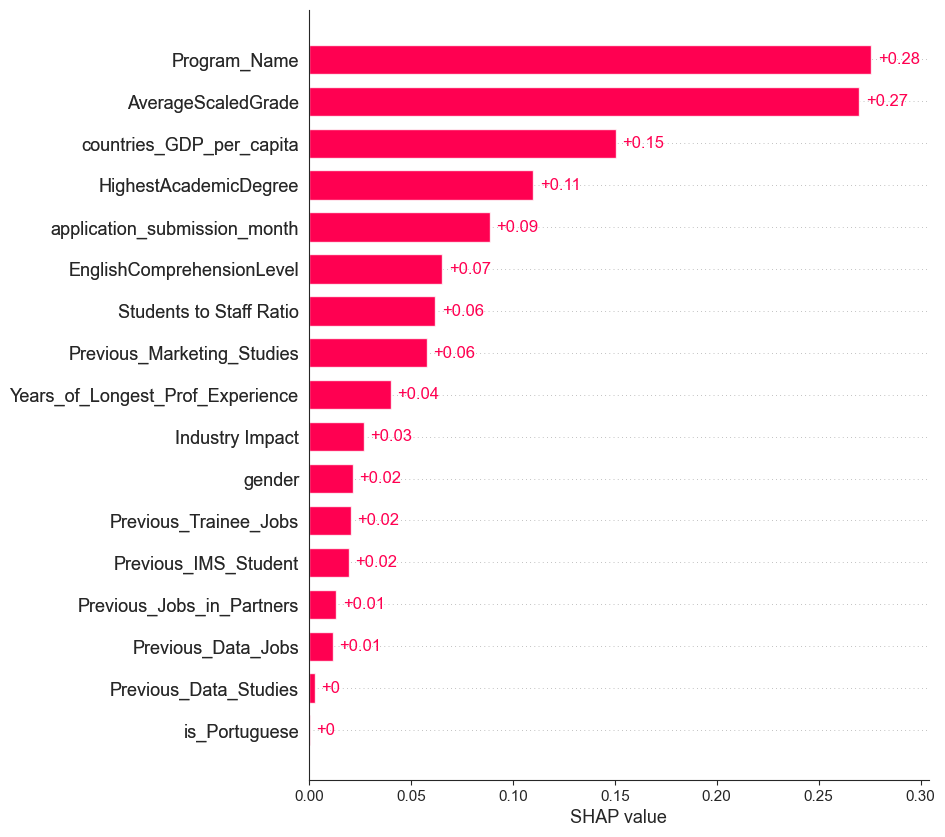

In [22]:
shap_exp = shap.Explanation(values = np.abs(shap_values.values).mean(axis = 0),
                            base_values = np.mean(shap_values.base_values, axis = 0),
                            data = np.mean(shap_values.data, axis = 0),
                            feature_names = X_grades_val_scaled.columns)

shap.plots.bar(shap_exp, max_display = len(X_grades_val_scaled.columns), show_data = False)

We observe that the program itself (`Program_Name`), encoded by its popularity, is the most relevant predictor of academic performance for the students that are admitted to Nova IMS's postgraduate and masters programs, followed closely by the average grade of their previous studies (`AverageScaledGrade`). The students' country of origin, encoded through its GDP _per capita_ (`countries_GDP_per_capita`), is also an important variable to predict final GPA, and so is the highest academic degree attained by these individuals prior to entering the program (`HighestAcademicDegree`). On the other hand, we have a group of variables with very little relevance to predict academic performance, highlighting the students' previous studies in the field of data (`Previous_Data_Studies`) and if they are Portuguese (`is_Portuguese`).

Perhaps our most important variable in terms of explainability, `gender` also exhibits little predictive power, which is a very positive indicator. Nonetheless, it is not completely neglected by the model - on average, gender tends to influence final GPA predictions on 0.02 GPA units.

The following visualization will help us understand more about the impact of each independent variable, detailing whether they help increase or decrease students' grades.

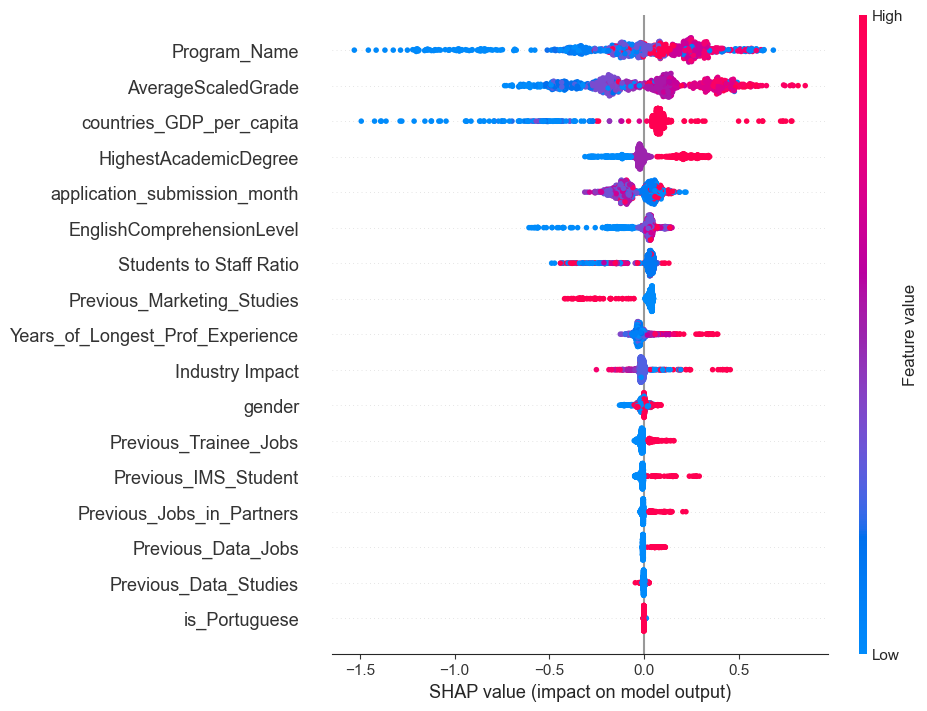

In [23]:
shap.plots.beeswarm(shap_values, max_display = len(X_grades_val_scaled.columns))

We can summarize our conclusions regarding variable importance as follows:
* `Program_Name` - students from less popular programs tend to have lower grades, with a higher magnitude than the opposite scenario. Naturally, there are some exceptions.
* `AverageScaledGrade`- as could be excpected, students that achieved higher grades in their past programs tend to be benefitted in terms of final GPA prediction, and vice-versa.
* `countries_GDP_per_capita` - the individuals who stem from countries with a highest GDP _per capita_ (which, usually - but not always - describes the country's level of development) tend to be assigned a higher final GPA by our Gradient Boosting model, and vice-versa.
* `HighestAcademicDegree` - similarly to the variables above, there is a positive relationship between this feature and the target, with higher GPAs predicted for students with higher previous academic degrees.
* `application_submission_month`- although the impact doesn't seem very significant, it appears that students who apply earlier in the year achieve higher conclusion grades for the program they were admitted to.
* `EnglishComprehensionLevel` - the visualization shows that the impact on final GPA prediction is bigger (negatively) for students with low English comprehension levels than it benefits students with higher English qualifications. We can think of this variable as an hygiene factor in Herzberg's two-factor theory.
* `Students to Staff Ratio` and `Industry Impact` - these attributes doesn't appear to have a defined linear correlation with the target, as we observe a relatively homogeneous distribution of the SHAP values for higher and lower values of these variables.
* `Previous_Marketing_Studies` - perhaps surprisingly, students with prior marketing education seem to achieve lower GPAs (as per our model predictions) compared to those without it.
* `Years_of_Longest_Prof_Experience` - back to Herzberg's two-factor theory, we can think of professional experience as a motivator for GPA prediction, with students having higher values being predicted higher grades because of it. A similar conclusion can be taken for `Previous_Trainee_Jobs`, `Previous_IMS_Student`, `Previous_Jobs_in_Partners`, and `Previous_Data_Jobs`.
* `gender` - apart from the two least relevant predictors, this is the second variable with the lowest maximum absolute impact on GPA predictions (confirmed in the cell below), which is very good and reassuring that our model does not promote discriminatory biases. However, as mentioned above, it is still not completely neglected, usually slightly benefitting women or non-binary students (higher values in our encoded variable).
* `Previous_Data_Studies` and `is_Portuguese` - these variables appear to be virtually irrelevant to predict final GPA, using our gradient boosting model.


In [24]:
shap_values_abs = np.abs(shap_values.values)
max_shap_values = np.max(shap_values_abs, axis = 0)

shap_abs_table = pd.DataFrame({"Variable": X_grades_val_scaled.columns,
                               "Maximum Absolute SHAP Value": max_shap_values})

shap_abs_table = shap_abs_table.sort_values(by = "Maximum Absolute SHAP Value", ascending = False)
shap_abs_table

,Variable,Maximum Absolute SHAP Value
4,Program_Name,1.530364
3,countries_GDP_per_capita,1.493655
2,AverageScaledGrade,0.852551
13,EnglishComprehensionLevel,0.607264
0,Students to Staff Ratio,0.487509
1,Industry Impact,0.456502
8,Previous_Marketing_Studies,0.419376
5,Years_of_Longest_Prof_Experience,0.390184
14,HighestAcademicDegree,0.347680
16,application_submission_month,0.312639


--------

<br><br>

With this, we conclude our code part of this study. You can check every step of the work in more detail, from an introduction to the task in hand, literature review, methodology, results, up to the conclusions and indications for future research, in the associated text document.

Thank you for following these notebooks' journey, and I hope you found it relevant, useful, and an interesting read. In any case, we are available to address any question or comment you may have.

Goodbye! 👋